In [13]:
import os
import numpy as np
import tifffile
from skimage.filters import threshold_otsu
from skimage.measure import label
from scipy.ndimage import binary_fill_holes
from skimage.segmentation import watershed
from skimage.filters import sobel
import re, numpy as np, tifffile, os
from pathlib import Path
from natsort import natsorted   # pip install natsort
import cv2
from skimage import measure
import matplotlib.pyplot as plt
from skimage.filters import sobel
from skimage.morphology import dilation, disk, closing, square, remove_small_objects
from scipy.ndimage import binary_fill_holes


### Load videos

In [5]:
pwd

'/Volumes/DAVIDESPERI/BCH/Data analysis/Sensors/pH_sensor/Video_analysis'

In [14]:
from pathlib import Path
import re
import numpy as np
import tifffile
from natsort import natsorted

# ------------------------- USER SETTINGS -------------------------
exp_folder  = Path(r'/Users/davidesperi/Desktop/video_analyisis_pipeline2/Video1_no_breathing')  # folder with images
ext         = ".tif"                           # or ".tiff", ".png", etc.
channel_map = {   # CFP (donor)
               "C002": "ch3",   # YFP / FRET
               }   # extra channel
start_frame = 0                  # (optional) ignore frames < this (int)
mask_folder = Path(r'/Users/davidesperi/Desktop/video_analyisis_pipeline2/S2_props_NN_RG_86015_mouse1_C002')  
# -----------------------------------------------------------------

# 0) discover analyzed T's from npy filenames (e.g., mouse1_C002_regiongrow_labels_T735.npy)
rx_npy = re.compile(r".*_T(\d+)\.npy$", re.IGNORECASE)
mask_files = [p for p in mask_folder.iterdir() if p.suffix.lower()=='.npy' and rx_npy.match(p.name)]
if not mask_files:
    raise RuntimeError(f"No mask npy files found in: {mask_folder}")

T_selected = sorted({int(rx_npy.match(p.name).group(1)) for p in mask_files if rx_npy.match(p.name)})
if start_frame:
    T_selected = [t for t in T_selected if t >= start_frame]
if not T_selected:
    raise RuntimeError("No T frames remain after applying start_frame filter.")

print(f"Found {len(T_selected)} labeled frames from masks, e.g.: {T_selected[:8]}{' ... ' if len(T_selected)>8 else ''}{T_selected[-3:] if len(T_selected)>8 else ''}")

# 1) collect all image filenames by channel (like before)
rx_img = re.compile(r".*_C(\d{3})T(\d+)" + re.escape(ext) + r"$", re.IGNORECASE)
files = [f for f in exp_folder.iterdir() if rx_img.match(f.name)]
if not files:
    raise RuntimeError(f"No matching image files found in folder: {exp_folder}")

frames_by_channel = {alias: [] for alias in channel_map.values()}

for f in files:
    chan_id, t_idx = rx_img.match(f.name).groups()
    frame_num = int(t_idx)
    if frame_num < start_frame:
        continue
    channel_alias = channel_map.get(f"C{chan_id}")
    if channel_alias is None:
        continue
    frames_by_channel[channel_alias].append((frame_num, f))

# natural sort within each channel
for ch in frames_by_channel:
    frames_by_channel[ch] = natsorted(frames_by_channel[ch], key=lambda x: x[0])

# 2) restrict to the T frames that have masks; also ensure all channels share the same T's
T_set = set(T_selected)
available_by_channel = {}
for ch, pairs in frames_by_channel.items():
    t_here = {t for t, _ in pairs}
    available_by_channel[ch] = t_here

# intersection of (mask T) with all channel T sets
common_T = T_set.copy()
for ch, tset in available_by_channel.items():
    common_T &= tset

dropped = sorted(T_set - common_T)
if dropped:
    print(f"⚠️ Dropping {len(dropped)} T frames (present in masks but missing in ≥1 channel): {dropped[:10]}{' ...' if len(dropped)>10 else ''}")

T_list = sorted(common_T)
if not T_list:
    raise RuntimeError("After alignment across channels, no common T frames remain.")

# 3) load ONLY the aligned T frames for each channel
frames_dict = {}
for ch, pairs in frames_by_channel.items():
    if not pairs:
        print(f"⚠️ Channel {ch} missing entirely — skipping load")
        continue
    # index by T for fast lookup
    idx = {t: p for (t, p) in pairs}
    missing_in_ch = [t for t in T_list if t not in idx]
    if missing_in_ch:
        print(f"⚠️ Channel {ch} missing {len(missing_in_ch)} frames (will be dropped from all).")
    # safely rebuild T_list as intersection on the fly
    # (but keep T_list stable by enforcing global common_T above)
    imgs = [tifffile.imread(idx[t]) for t in T_list]
    arr  = np.stack(imgs, axis=0).astype(np.float32)  # (N,H,W)
    frames_dict[ch] = arr
    print(f"Loaded {arr.shape[0]} frames for {ch}: shape {arr.shape}")

# final sanity: all loaded channels must share identical frame count
n_frames = {ch: arr.shape[0] for ch, arr in frames_dict.items()}
if len(set(n_frames.values())) != 1:
    raise AssertionError(f"Channel frame counts mismatch: {n_frames}")
print(f"✅ All channels aligned with {list(n_frames.values())[0]} frames")

# expose T_list for downstream tracking/analysis; aligns 1:1 with axis-0 in frames_dict[ch]
print("Aligned T_list length:", len(T_list))


Found 800 labeled frames from masks, e.g.: [1, 2, 3, 4, 5, 6, 7, 8] ... [798, 799, 800]
⚠️ Dropping 138 T frames (present in masks but missing in ≥1 channel): [2, 5, 14, 15, 24, 36, 37, 39, 43, 44] ...
Loaded 662 frames for ch3: shape (662, 512, 512)
✅ All channels aligned with 662 frames
Aligned T_list length: 662


### Play the video to double check

In [15]:
def play_video_cv(frames, fps=10, window_name='Video', normalize=True):
    """
    Play video frames using OpenCV.
    """
    wait_ms = int(1000 / fps)

    for i, frame in enumerate(frames):
        if normalize:
            frame_disp = cv2.normalize(frame, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        else:
            frame_disp = frame.astype(np.uint8)

        cv2.imshow(window_name, frame_disp)
        key = cv2.waitKey(wait_ms)
        if key == 27:  # ESC to quit
            break

    cv2.destroyAllWindows()


In [16]:
play_video_cv(frames_dict["ch3"], fps=100, window_name="RFP Channel")

### Manual anchor point selection

In [17]:
def collect_anchor_points(frames, every_n=10, scale=1.0, window_name="Click Anchor Points"):
    """
    Let user click one anchor point every N frames.

    Parameters
    ----------
    frames : ndarray, shape (T, H, W)
        Image stack (e.g., ch3)
    every_n : int
        Click every N frames (e.g. 10 = frames 0, 10, 20…)
    scale : float
        Resize factor for easier clicking (1.0 = no scaling)
    window_name : str
        OpenCV window name

    Returns
    -------
    anchor_points : dict
        frame_index -> (x, y)
    """
    anchor_points = {}
    T = frames.shape[0]
    selected_frames = list(range(0, T, every_n))

    print("👉 Click one anchor point per frame.")
    print("   Press any key to go to next frame. ESC to quit early.")

    for t in selected_frames:
        img = frames[t]
        img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        disp = cv2.resize(img, (0, 0), fx=scale, fy=scale)
        disp = cv2.cvtColor(disp, cv2.COLOR_GRAY2BGR)

        clicked = []

        def _click(event, x, y, flags, param):
            if event == cv2.EVENT_LBUTTONDOWN:
                clicked.clear()
                clicked.append((x / scale, y / scale))  # rescale back

        cv2.namedWindow(window_name)
        cv2.setMouseCallback(window_name, _click)

        while True:
            disp_copy = disp.copy()
            if clicked:
                cv2.circle(disp_copy, (int(clicked[0][0] * scale), int(clicked[0][1] * scale)), 4, (0, 0, 255), -1)
            cv2.imshow(window_name, disp_copy)
            key = cv2.waitKey(30)
            if key != -1:  # any key pressed
                break
            if cv2.getWindowProperty(window_name, 0) < 0:
                break  # window closed

        cv2.destroyWindow(window_name)
        if clicked:
            anchor_points[t] = clicked[0]
        else:
            print(f"⚠️ Frame {t}: no point clicked — skipping")

    print("✅ Finished anchor point selection.")
    return anchor_points

In [18]:
anchor_points = collect_anchor_points(frames_dict["ch3"], every_n=5, scale=1.0)

👉 Click one anchor point per frame.
   Press any key to go to next frame. ESC to quit early.
✅ Finished anchor point selection.


In [19]:

anchor_points

{0: (127.0, 192.0),
 5: (128.0, 193.0),
 10: (128.0, 193.0),
 15: (128.0, 193.0),
 20: (128.0, 193.0),
 25: (131.0, 196.0),
 30: (120.0, 188.0),
 35: (124.0, 195.0),
 40: (129.0, 198.0),
 45: (127.0, 196.0),
 50: (127.0, 198.0),
 55: (127.0, 198.0),
 60: (128.0, 201.0),
 65: (128.0, 201.0),
 70: (127.0, 204.0),
 75: (127.0, 204.0),
 80: (125.0, 203.0),
 85: (125.0, 203.0),
 90: (125.0, 203.0),
 95: (124.0, 201.0),
 100: (127.0, 205.0),
 105: (127.0, 209.0),
 110: (127.0, 209.0),
 115: (128.0, 208.0),
 120: (125.0, 204.0),
 125: (125.0, 206.0),
 130: (125.0, 211.0),
 135: (127.0, 211.0),
 140: (128.0, 212.0),
 145: (129.0, 210.0),
 150: (129.0, 213.0),
 155: (129.0, 209.0),
 160: (129.0, 212.0),
 165: (129.0, 212.0),
 170: (129.0, 211.0),
 175: (129.0, 211.0),
 180: (129.0, 213.0),
 185: (129.0, 213.0),
 190: (127.0, 213.0),
 195: (127.0, 218.0),
 200: (127.0, 213.0),
 205: (127.0, 212.0),
 210: (128.0, 214.0),
 215: (128.0, 216.0),
 220: (129.0, 216.0),
 225: (129.0, 216.0),
 230: (129

In [20]:
import json

with open("anchor_points.json", "w") as f:
    json.dump({int(k): v for k, v in anchor_points.items()}, f)

In [21]:
import json

with open("anchor_points.json", "r") as f:
    anchor_points = json.load(f)

# Optional: convert string keys back to int if needed
anchor_points = {int(k): v for k, v in anchor_points.items()}

### Global drift correction

shift_vectors shape: (662, 2)


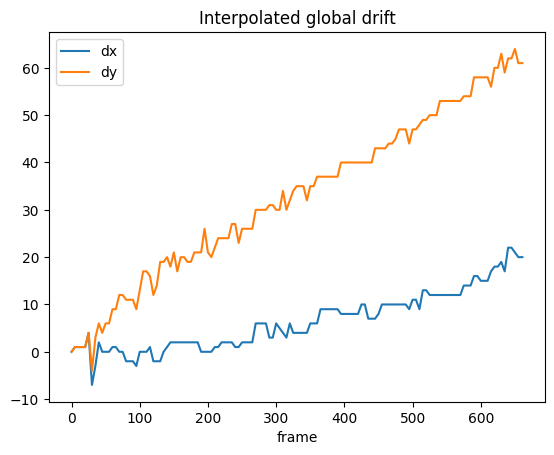

In [22]:
import numpy as np
from scipy.interpolate import interp1d
import json

image_stack = frames_dict["ch3"]
# ------------------------------------------------------------
# 1.  Load or reuse the anchor_points you just collected
# ------------------------------------------------------------
# If you saved them:
# anchor_points = json.load(open("anchor_points.json"))

# Ensure keys are ints, values are (x,y)
anchor_points = {int(k): tuple(v) for k, v in anchor_points.items()}

# ------------------------------------------------------------
# 2.  Interpolate per‑frame global shift
# ------------------------------------------------------------
T = image_stack.shape[0]
frames = np.arange(T)

# Sort anchors
anchor_frames = np.array(sorted(anchor_points.keys()))
anchor_xy     = np.array([anchor_points[f] for f in anchor_frames])  # shape (M, 2)

# Use the *difference* from the first anchor as drift
dx = anchor_xy[:,0] - anchor_xy[0,0]
dy = anchor_xy[:,1] - anchor_xy[0,1]

fx = interp1d(anchor_frames, dx, kind='linear', fill_value='extrapolate')
fy = interp1d(anchor_frames, dy, kind='linear', fill_value='extrapolate')

shift_vectors = np.stack([fx(frames), fy(frames)], axis=-1)   # (T, 2)
np.save("shift_vectors.npy", shift_vectors)
print("shift_vectors shape:", shift_vectors.shape)  # (T, 2)

# Optional sanity‑check plot
plt.plot(frames, shift_vectors[:,0], label='dx')
plt.plot(frames, shift_vectors[:,1], label='dy')
plt.title("Interpolated global drift"); plt.xlabel("frame"); plt.legend();
plt.savefig("Interpolated_global_drift.tif", dpi = 300)
plt.show()


In [23]:
def warp_stack_with_shift(frames, shift_vectors):
    """
    Applies global affine shift correction to all frames.

    Parameters
    ----------
    frames : ndarray, shape (T, H, W)
        Original image stack
    shift_vectors : ndarray, shape (T, 2)
        (dx, dy) per frame from anchor interpolation

    Returns
    -------
    warped_stack : ndarray, shape (T, H, W)
        Globally corrected image stack
    """
    T, H, W = frames.shape
    warped_stack = np.zeros_like(frames)

    for t in range(T):
        dx, dy = shift_vectors[t]
        M = np.float32([
            [1, 0, -dx],  # translate left
            [0, 1, -dy],  # translate up
        ])
        warped = cv2.warpAffine(
            frames[t], M, (W, H),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_CONSTANT,  # prevents reflection
            borderValue=0                     # fill with black
        )
        warped_stack[t] = warped

    return warped_stack


In [16]:
import imagecodecs
print(imagecodecs.__version__)

2025.8.2


In [31]:
# image_stack = frames_dict["ch3"]
drift_corrected_stack = warp_stack_with_shift(image_stack, shift_vectors)

# Optional: save for later use
tifffile.imwrite("drift_corrected_stack.tif", drift_corrected_stack)

### Load maunally defined masks

In [32]:
# --- Settings ---
from pathlib import Path
import re, numpy as np
from skimage.measure import label as cc_label

use_T_list = T_list if 'T_list' in globals() else None
target_shape = next(iter(frames_dict.values())).shape[1:3] if 'frames_dict' in globals() else None  # (H,W)

# --- Helpers ---
_rx = re.compile(r".*_T(\d+)\.npy$", re.IGNORECASE)

def _load_one_mask_npy(fp):
    """Return dict {id: 2D bool} from any supported .npy format."""
    arr = np.load(fp, allow_pickle=True)
    if arr.dtype == object and isinstance(arr.item(), dict):
        d = arr.item()
        return {int(k): np.asarray(v).astype(bool) for k, v in d.items()}
    a = np.asarray(arr)
    if a.ndim == 2:
        # boolean full mask or labeled image
        if a.dtype == bool or set(np.unique(a).tolist()) <= {0,1}:
            L = cc_label(a.astype(np.uint8))
        else:
            L = a.astype(np.int32)
        return {int(l): (L == l) for l in np.unique(L) if l != 0}
    if a.ndim == 3:  # (n_cells, H, W) boolean stack
        return {int(i+1): a[i].astype(bool) for i in range(a.shape[0])}
    raise ValueError(f"Unsupported mask shape {a.shape} in {fp}")

def _dict_to_label(mask_dict, shape=None):
    """{id: 2D bool} -> 2D int labels (0 bg)."""
    if not mask_dict:
        if shape is None:
            raise ValueError("Empty mask_dict and no shape provided.")
        return np.zeros(shape, np.int32)
    if shape is None:
        shape = next(iter(mask_dict.values())).shape
    L = np.zeros(shape, np.int32)
    for k, m in mask_dict.items():
        if m.shape != shape:
            raise ValueError(f"Mask {k} has shape {m.shape} != {shape}")
        L[m] = int(k)
    return L

# --- Discover files ---
candidates = []
for p in mask_folder.iterdir():
    m = _rx.match(p.name)
    if p.suffix.lower() == ".npy" and m:
        candidates.append((int(m.group(1)), p))
if not candidates:
    raise RuntimeError(f"No .npy masks with _T### in {mask_folder}")

# --- Choose order: follow existing T_list if available; else sort by T ---
if use_T_list is not None:
    idx = {t: p for t, p in candidates}
    ordered = [(t, idx[t]) for t in use_T_list if t in idx]
    missing = [t for t in use_T_list if t not in idx]
    if missing:
        print(f"⚠️ Missing masks for {len(missing)} frames from T_list (e.g. {missing[:10]})")
else:
    ordered = sorted(candidates, key=lambda x: x[0])

# --- Load -> dict -> label; stack to (N,H,W) as 'raw_labeled_masks' ---
label_frames = []
T_order = []
for T, fp in ordered:
    d = _load_one_mask_npy(fp)
    L = _dict_to_label(d, shape=target_shape)
    label_frames.append(L.astype(np.int32))
    T_order.append(T)

raw_labeled_masks = np.stack(label_frames, axis=0)  # (N,H,W) int32, 0=background
print("raw_labeled_masks:", raw_labeled_masks.shape, " | first/last T:", T_order[:3], "...", T_order[-3:])


raw_labeled_masks: (662, 512, 512)  | first/last T: [1, 3, 4] ... [798, 799, 800]


In [33]:
def warp_mask_stack_with_shift(masks, shift_vectors):
    """
    Applies the same global shifts used for drift‑correcting images
    to a stack of binary or labeled masks, preserving label integers.

    Parameters
    ----------
    masks : ndarray, shape (T, H, W), uint8 / uint16 / bool
        Original mask stack (e.g., global Otsu masks or hand labels)
    shift_vectors : ndarray, shape (T, 2)
        (dx, dy) shift per frame, identical to the one used for images

    Returns
    -------
    warped_masks : ndarray, shape (T, H, W), same dtype as `masks`
        Shift‑corrected mask stack
    """
    T, H, W = masks.shape
    warped_masks = np.zeros_like(masks)

    for t in range(T):
        dx, dy = shift_vectors[t]
        M = np.float32([[1, 0, -dx],
                        [0, 1, -dy]])          # same sign convention

        warped = cv2.warpAffine(
            masks[t], M, (W, H),
            flags=cv2.INTER_NEAREST,           # <-- preserve discrete labels
            borderMode=cv2.BORDER_CONSTANT,
            borderValue=0                      # outside area = background
        )
        warped_masks[t] = warped

    return warped_masks

def play_overlay_video(frames, labels, fps=100, alpha=1):
    """
    Show a live video with Otsu labels overlaid on the raw frames.

    Parameters
    ----------
    frames  : (T, H, W) ndarray  – original grayscale stack
    labels  : (T, H, W) ndarray  – labeled Otsu components
    fps     : int                – playback speed
    alpha   : float [0–1]        – overlay opacity
    """
    wait_ms = int(1000 / fps)
    lut = (np.random.rand(labels.max() + 1, 3) * 255).astype(np.uint8)
    lut[0] = 0                    # background = black

    for t in range(frames.shape[0]):
        frame = frames[t]
        label_img = labels[t]

        # convert raw to grayscale RGB
        gray_rgb = cv2.normalize(frame, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        gray_rgb = cv2.cvtColor(gray_rgb, cv2.COLOR_GRAY2BGR)

        # pseudo‑color the labels
        colored = lut[label_img]
        overlay = cv2.addWeighted(gray_rgb, 1 - alpha, colored, alpha, 0)

        cv2.imshow("Overlay", overlay)
        key = cv2.waitKey(wait_ms)
        if key == 27:   # ESC to exit
            break

    cv2.destroyAllWindows()

In [34]:
import cv2
import numpy as np

def save_overlay_video(frames, labels, output_path="overlay.mp4", fps=30, alpha=1.0):
    """
    Save a video with colored labels overlaid on grayscale frames.

    Parameters
    ----------
    frames  : (T, H, W) ndarray
        Grayscale stack
    labels  : (T, H, W) ndarray
        Labeled mask stack
    output_path : str
        Output video filename
    fps : int
        Frames per second
    alpha : float
        Overlay opacity
    """
    T, H, W = frames.shape

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video = cv2.VideoWriter(output_path, fourcc, fps, (W, H))

    rng = np.random.default_rng(42)
    lut = (rng.random((labels.max() + 1, 3)) * 255).astype(np.uint8)
    lut[0] = 0  # background = black

    for t in range(T):
        frame = frames[t]
        label_img = labels[t]

        gray = cv2.normalize(frame, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        gray_rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

        colored = lut[label_img]
        overlay = cv2.addWeighted(gray_rgb, 1 - alpha, colored, alpha, 0)

        video.write(overlay)

    video.release()
    print(f"Saved video to: {output_path}")

In [35]:
# 3. Warp masks by exactly the same shifts
labeled_masks = warp_mask_stack_with_shift(raw_labeled_masks, shift_vectors)

In [38]:
play_overlay_video(image_stack, raw_labeled_masks, fps=50, alpha=1)
save_overlay_video(image_stack, raw_labeled_masks, output_path="overlay.mp4", fps=80, alpha=1)

Saved video to: overlay.mp4


In [39]:
play_overlay_video(drift_corrected_stack, labeled_masks, fps=50, alpha=1)
save_overlay_video(drift_corrected_stack, labeled_masks, output_path="overlay_drift_corrected.mp4", fps=80, alpha=1)

Saved video to: overlay_drift_corrected.mp4


### Centroid-based tracking

In [40]:
import pandas as pd
from skimage.measure import regionprops

def extract_centroids_from_masks(mask_stack):
    """
    Extract centroids from labeled masks across frames.

    Returns:
    - DataFrame with columns: frame, x, y, label (original label ID)
    """
    records = []
    for t, mask in enumerate(mask_stack):
        for r in regionprops(mask):
            y, x = r.centroid
            records.append({'frame': t, 'x': x, 'y': y, 'label': r.label})
    return pd.DataFrame.from_records(records)


In [41]:
# 2) Extract centroids from DRIFT-CORRECTED masks
df_centroids = extract_centroids_from_masks(raw_labeled_masks).sort_values('frame')

# 3) Track with TrackPy (persistent IDs = 'particle' → remapped to 1..K as 'cell_id')
import trackpy as tp, numpy as np
linked_df = tp.link_df(df_centroids, search_range=20, memory=100)
first_appear = linked_df.groupby('particle')['frame'].min().sort_values()
id_map = {p:i+1 for i,p in enumerate(first_appear.index)}
linked_df['cell_id'] = linked_df['particle'].map(id_map).astype(int)

Frame 661: 39 trajectories present.


In [42]:
from scipy.spatial.distance import cdist
import numpy as np
import pandas as pd

def merge_close_tracks(tracked_df, dist_tol=20):
    """
    Simplified merge: any trajectories whose centroids are within dist_tol pixels
    (using mean of last few points) are merged as one cell.
    """
    df = tracked_df.copy()
    grouped = df.groupby("cell_id")
    tail = grouped.tail(5)

    info = pd.DataFrame({
        "x_mean": tail.groupby("cell_id")["x"].mean(),
        "y_mean": tail.groupby("cell_id")["y"].mean()
    })

    D = cdist(info[["x_mean", "y_mean"]], info[["x_mean", "y_mean"]])
    ids = info.index.to_numpy()
    auto_mapping = {}

    for i, id_a in enumerate(ids):
        for j, id_b in enumerate(ids):
            if j <= i: 
                continue
            if D[i, j] < dist_tol:
                auto_mapping[id_b] = id_a

    if auto_mapping:
        df["cell_id"] = df["cell_id"].replace(auto_mapping)
        print(f"Merged {len(auto_mapping)} pairs by spatial proximity.")
    else:
        print("No merges performed.")

    # reindex IDs
    id_map = {cid: i+1 for i, cid in enumerate(sorted(df["cell_id"].unique()))}
    df["cell_id"] = df["cell_id"].map(id_map)
    return df


In [43]:
merged = merge_close_tracks(linked_df, dist_tol=50)



Merged 139 pairs by spatial proximity.


In [44]:
def remove_blinking_tracks(df, min_len=5, max_gap=200):
    """
    Remove trajectories that appear for too few frames
    or disappear for long gaps (blinking/intermittent).
    """
    clean_ids = []
    for cid, g in df.groupby("cell_id"):
        frames = np.sort(g["frame"].unique())
        if len(frames) < min_len:
            continue
        diffs = np.diff(frames)
        if len(diffs) == 0 or np.max(diffs) <= max_gap:
            clean_ids.append(cid)

    kept = df[df["cell_id"].isin(clean_ids)].copy()
    print(f"Kept {len(clean_ids)} / {df['cell_id'].nunique()} trajectories "
          f"(min_len≥{min_len}, max_gap≤{max_gap})")
    return kept


In [45]:
cleaned = remove_blinking_tracks(merged, min_len=5, max_gap=10)

Kept 18 / 121 trajectories (min_len≥5, max_gap≤10)


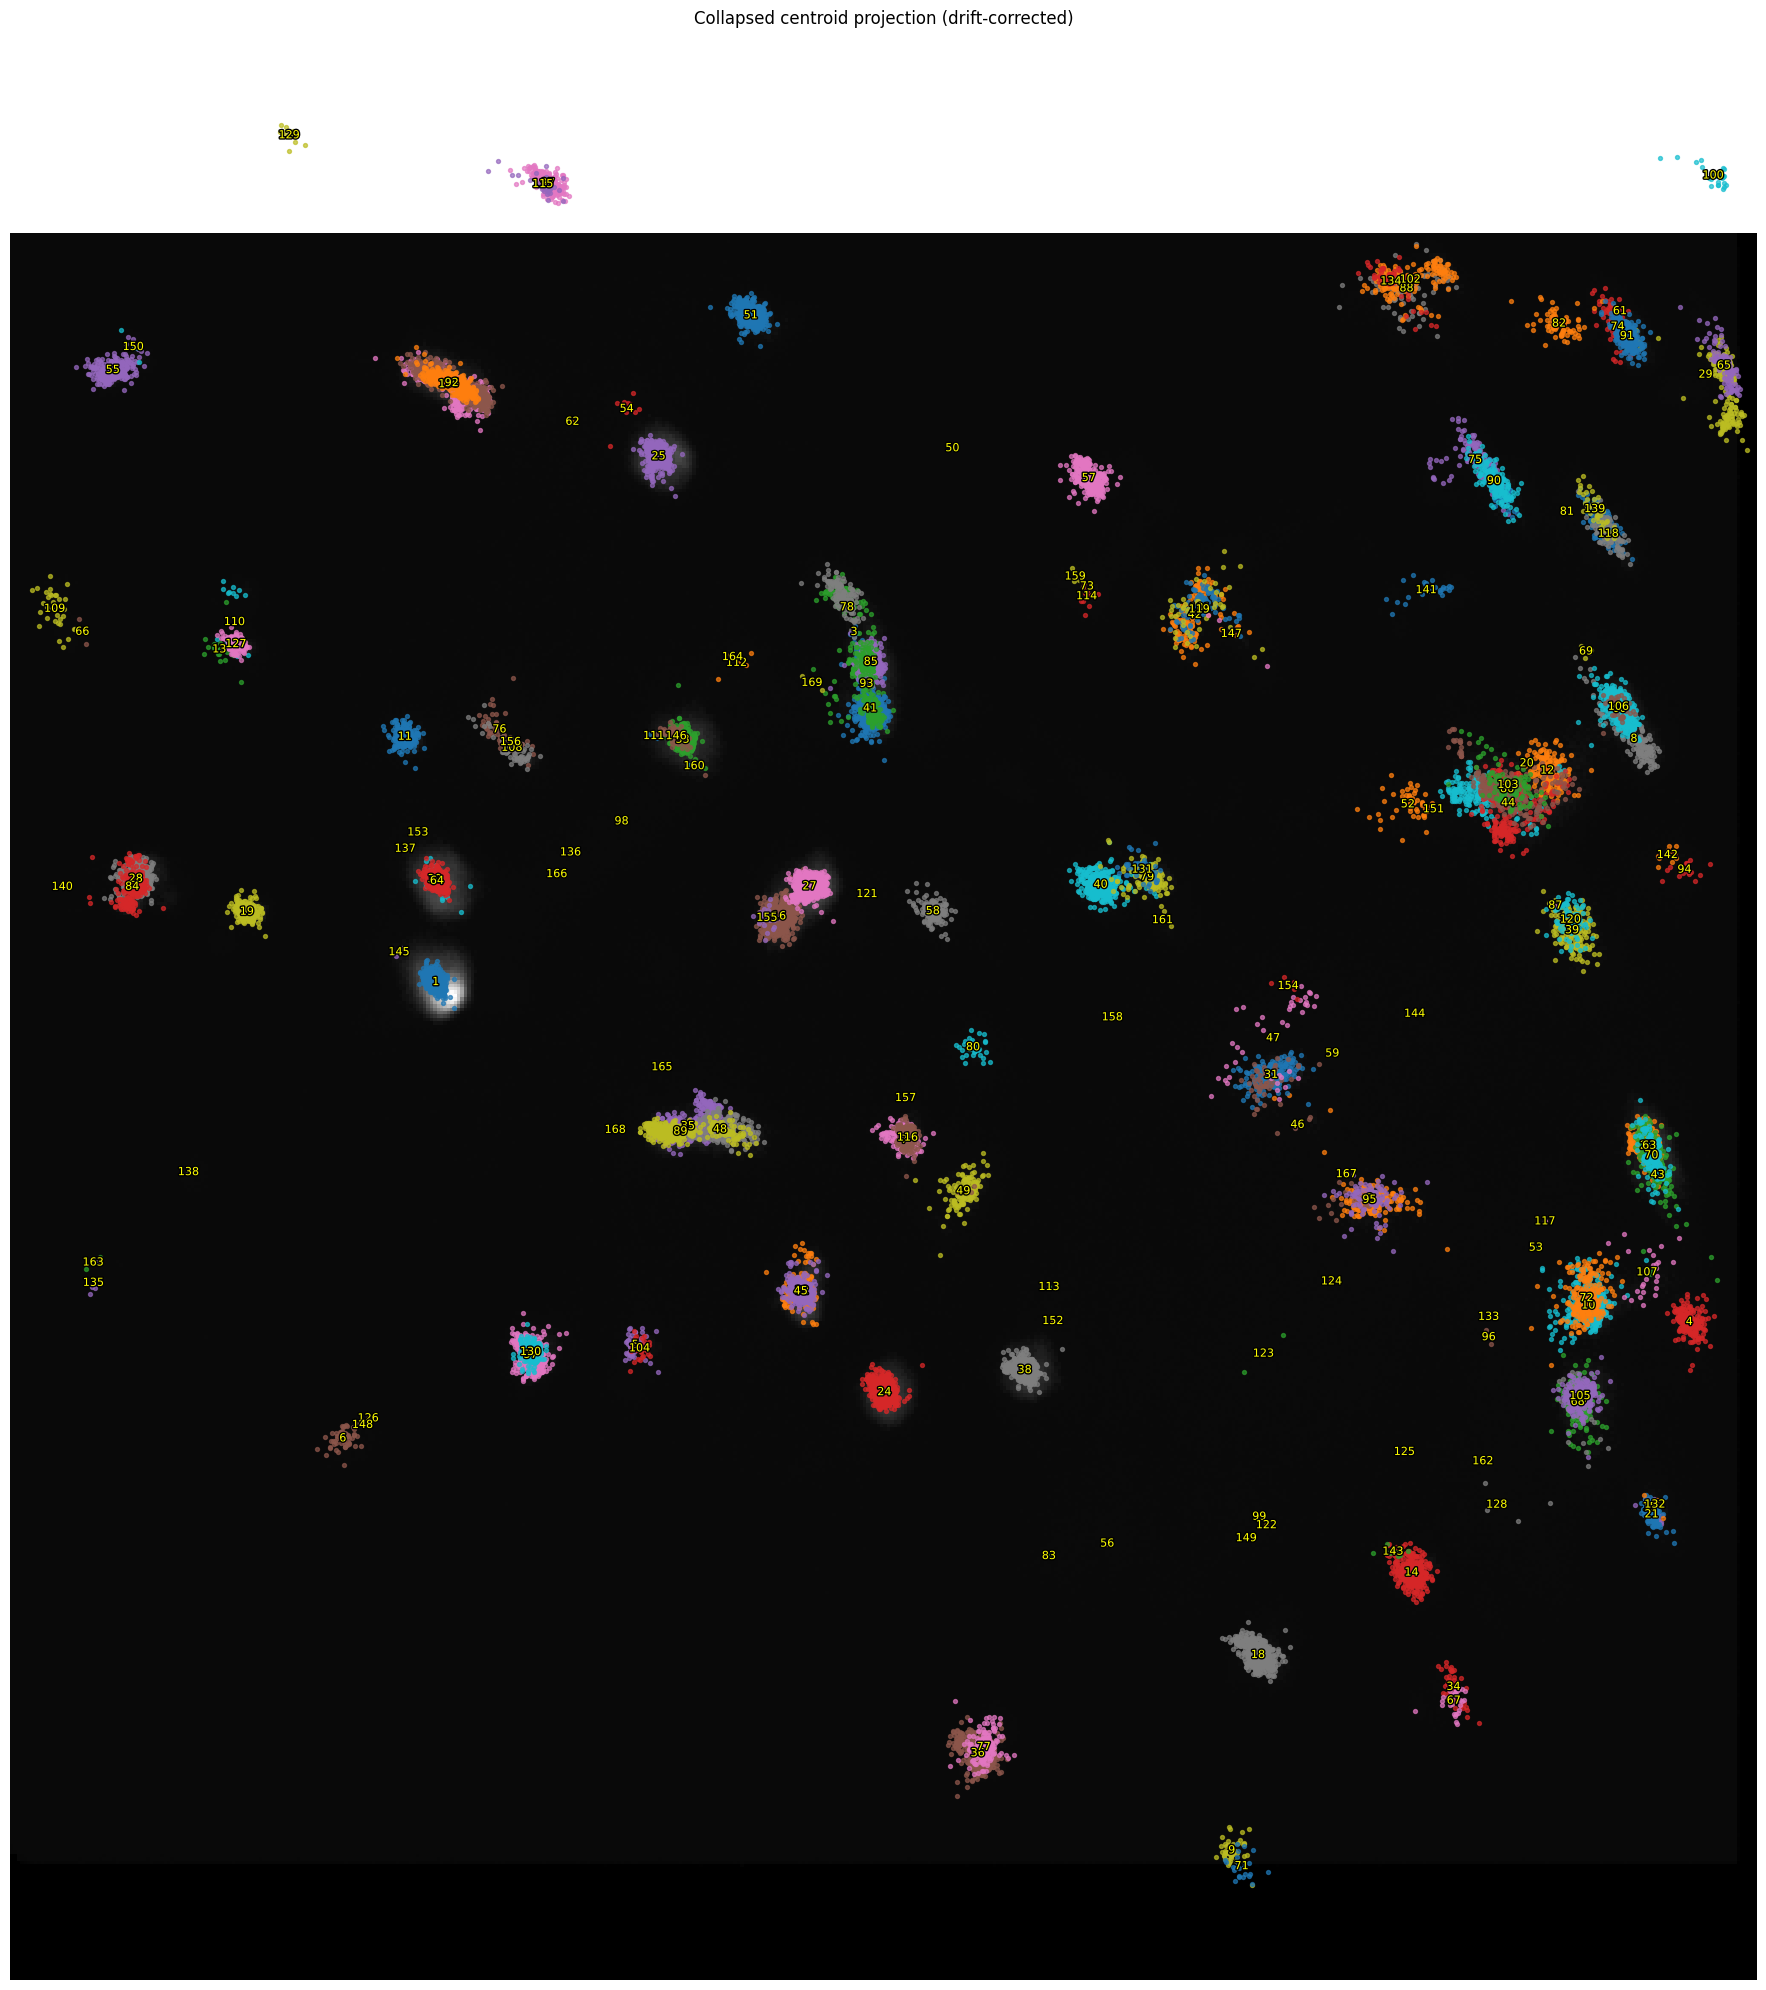

In [46]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import pandas as pd
import numpy as np

data = linked_df.copy()

def project_centroids_2D(frames, tracked_df, point_size=5, alpha=0.5, fontsize=8):
    """
    Plot all centroid positions (drift-corrected) collapsed into one 2D projection.
    Helps visually identify overlapping / duplicated tracks.
    """
    H, W = frames.shape[1:]
    bg = np.median(frames, axis=0)

    fig, ax = plt.subplots(figsize=(20, 20))
    ax.imshow(
    bg,
    cmap="gray",
    interpolation="none",        # exact pixel display, no smoothing
    extent=(0, W, H, 0),         # preserve coordinate system
    origin="upper",              # match image array orientation
)

    for cid, group in tracked_df.groupby("cell_id"):
        xvals = pd.to_numeric(group["x"], errors="coerce")
        yvals = pd.to_numeric(group["y"], errors="coerce")

        ax.scatter(xvals, yvals, s=point_size, alpha=alpha, label=f"{cid}")

        x_mean = float(np.nanmean(xvals))
        y_mean = float(np.nanmean(yvals))
        ax.text(
            x_mean, y_mean, str(int(cid)),
            color="yellow", fontsize=fontsize,
            ha="center", va="center",
            path_effects=[pe.withStroke(linewidth=2, foreground="black")]
        )

    ax.set_title("Collapsed centroid projection (drift-corrected)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


# --- drift correction only on `data` ---
data["x_corr"] = data.apply(lambda r: r["x"] - shift_vectors[int(r["frame"]), 0], axis=1)
data["y_corr"] = data.apply(lambda r: r["y"] - shift_vectors[int(r["frame"]), 1], axis=1)

# --- ensure numeric ---
data["x_corr"] = pd.to_numeric(data["x_corr"], errors="coerce")
data["y_corr"] = pd.to_numeric(data["y_corr"], errors="coerce")

# --- drop old to avoid duplicate column names ---
data = data.drop(columns=["x", "y"], errors="ignore")

# --- plot ---
project_centroids_2D(
    drift_corrected_stack,
    data.rename(columns={"x_corr": "x", "y_corr": "y"}),
    point_size=8,
    alpha=0.7
)


In [47]:
same_cells =[]
              
                # <-- fill this list manually

merged = linked_df.copy()

# Build mapping from all merge groups
mapping = {}
for group in same_cells:
    keep = group[0]
    for merge in group[1:]:
        mapping[merge] = keep

# Apply transitive closure so A←B←C all collapse to one
for k in list(mapping.keys()):
    while mapping.get(mapping[k], None) in mapping:
        mapping[k] = mapping[mapping[k]]

# Apply the mapping
if mapping:
    merged["cell_id"] = merged["cell_id"].replace(mapping)
    print(f"Merged {len(mapping)} IDs.")
else:
    print("No manual merges defined.")

# Re-index cleanly
id_map = {cid: i + 1 for i, cid in enumerate(sorted(merged["cell_id"].unique()))}
merged["cell_id"] = merged["cell_id"].map(id_map)


No manual merges defined.


In [52]:
#Optional) keep long tracks if you expect ~14 stable cells
min_frames = 60
good = (linked_df.groupby('cell_id')['frame'].nunique() >= min_frames)
keep_ids = good[good].index
linked_df = linked_df[linked_df['cell_id'].isin(keep_ids)].copy()
print("Tracked IDs (corrected coords):", np.unique(linked_df['cell_id']))


Tracked IDs (corrected coords): [  1   2   3   4   7   8  10  11  12  14  16  17  18  19  20  21  22  23
  24  25  26  27  28  29  30  31  32  33  35  36  37  38  39  40  41  42
  43  44  45  46  48  49  51  55  57  58  60  63  64  65  68  70  72  74
  75  77  78  79  81  82  84  85  86  88  89  90  91  92  93  95  97 101
 102 103 105 108 116 118 120 127 130 146]


In [49]:
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def play_tracking_overlay_corrected(frames, tracked_df, fps=30, radius=3, alpha=1.0):
    """
    Display tracked centroids frame-by-frame over drift-corrected stack in Jupyter.
    """
    T, H, W = frames.shape
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # pre-aggregate coordinates per cell per frame
    grouped = (
        tracked_df.groupby(['frame', 'cell_id'], as_index=False)
        .agg({'x': 'mean', 'y': 'mean'})
    )
    
    for t in range(T):
        ax.clear()
        ax.imshow(frames[t], cmap='gray')

        df_t = tracked_df[tracked_df['frame'] == t]
        for _, row in df_t.iterrows():
            circ = patches.Circle((row['x'], row['y']), radius=radius,
                                  color='red', alpha=alpha, fill=True)
            ax.add_patch(circ)
            # ax.text(row['x'] + 4, row['y'], str(int(row['cell_id'])),
                    # color='yellow', fontsize=7)

        ax.set_title(f"Frame {t}")
        ax.axis('off')

        clear_output(wait=True)
        display(fig)
        plt.pause(1 / fps)

    plt.close()


In [50]:
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def play_tracking_overlay_with_mask(frames, masks, tracked_df, fps=30, radius=3, alpha=1.0):
    """
    Display tracked centroids frame-by-frame over image stack,
    with segmentation mask outlines overlaid.
    
    frames: array of shape (T, H, W)
    masks:  array of shape (T, H, W), binary or labeled masks
    tracked_df: DataFrame with columns ['frame', 'x', 'y', 'cell_id']
    """
    T, H, W = frames.shape
    fig, ax = plt.subplots(figsize=(6, 6))

    for t in range(T):
        ax.clear()

        # show image
        ax.imshow(frames[t], cmap='gray')

        # show mask outline
        # works for binary masks or labeled masks
        mask_t = masks[t]
        ax.contour(mask_t > 0, levels=[0.5], colors='cyan', linewidths=1)

        # show centroids
        df_t = tracked_df[tracked_df['frame'] == t]
        for _, row in df_t.iterrows():
            circ = patches.Circle(
                (row['x'], row['y']),
                radius=radius,
                color='red',
                alpha=alpha,
                fill=True
            )
            ax.add_patch(circ)

        ax.set_title(f"Frame {t}")
        ax.axis('off')

        clear_output(wait=True)
        display(fig)
        plt.pause(1 / fps)

    plt.close()

In [51]:
play_tracking_overlay_corrected(image_stack, linked_df, fps=100000, radius=3, alpha=1.0)

KeyboardInterrupt: 

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

def play_single_cell_trail(frames, tracked_df, cell_id, fps=5, radius=4, trail_color='yellow'):
    """
    Show one tracked cell with its past trajectory.
    
    frames: array (T, H, W)
    tracked_df: DataFrame with columns ['frame', 'cell_id', 'x', 'y']
    cell_id: integer cell track to display
    """
    fig, ax = plt.subplots(figsize=(6, 6))

    cell_track = (
        tracked_df[tracked_df['cell_id'] == cell_id]
        .sort_values('frame')
        .reset_index(drop=True)
    )

    for t in range(frames.shape[0]):
        ax.clear()
        ax.imshow(frames[t], cmap='gray')

        # positions up to current frame
        past = cell_track[cell_track['frame'] <= t]

        if len(past) > 0:
            # draw trail
            ax.plot(past['x'], past['y'], color=trail_color, linewidth=2)

            # draw current point
            x_now = past.iloc[-1]['x']
            y_now = past.iloc[-1]['y']
            ax.scatter(x_now, y_now, color='red', s=80)

        ax.set_title(f"Cell {cell_id} — Frame {t}")
        ax.axis('off')

        clear_output(wait=True)
        display(fig)
        plt.pause(1 / fps)

    plt.close()

In [59]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def save_tracking_overlay_video(frames, tracked_df, output_path="tracked_overlay.mp4", fps=50, radius=3):
    """
    Save a grayscale video with cell tracking overlay: circles + cell_id labels.

    Parameters
    ----------
    frames : ndarray (T, H, W)
        Drift-corrected grayscale frames
    tracked_df : DataFrame
        Must contain columns: [frame, cell_id, x, y]
    output_path : str
        Path to save output video (e.g. 'output.mp4')
    fps : int
        Frames per second
    radius : int
        Radius of red tracking dot
    """
    T, H, W = frames.shape
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Use 'XVID' for .avi
    video = cv2.VideoWriter(output_path, fourcc, fps, (W, H))

    for t in range(T):
        # Convert grayscale to BGR
        frame = cv2.normalize(frames[t], None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        frame_bgr = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)

        # Draw tracked cell positions
        df_t = tracked_df[tracked_df['frame'] == t]
        for _, row in df_t.iterrows():
            x, y = int(row['x']), int(row['y'])
            cell_id = int(row['cell_id'])

            cv2.circle(frame_bgr, (x, y), radius, (0, 0, 255), -1)
            cv2.putText(frame_bgr, str(cell_id), (x + 5, y),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 255), 1, cv2.LINE_AA)

        # ✅ Add frame number at top-right
        frame_label = f"Frame {t}"
        text_size, _ = cv2.getTextSize(frame_label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
        text_width = text_size[0]
        cv2.putText(frame_bgr, frame_label, (W - text_width - 10, 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA)

        video.write(frame_bgr)

    video.release()
    print(f"✅ Video saved to: {output_path}")


In [56]:
import cv2
import numpy as np

def save_tracking_trail_video(
    frames,
    tracked_df,
    output_path="tracked_trails.mp4",
    fps=30,
    radius=3,
    trail_length=None,
    selected_cell_id=None,
    show_frame_number=True
):
    """
    Save a grayscale video with tracking overlay:
    - current centroid = red dot
    - past linked positions = yellow trail

    Parameters
    ----------
    frames : ndarray (T, H, W)
        Grayscale image stack
    tracked_df : DataFrame
        Must contain columns: ['frame', 'cell_id', 'x', 'y']
    output_path : str
        Output video path
    fps : int
        Frames per second
    radius : int
        Radius of centroid dot
    trail_length : int or None
        Number of past frames to show in the trail.
        If None, show full history.
    selected_cell_id : int or None
        If set, only plot this one cell.
        If None, plot all tracked cells.
    show_frame_number : bool
        Whether to display frame number
    """
    T, H, W = frames.shape

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video = cv2.VideoWriter(output_path, fourcc, fps, (W, H))

    # optional filtering to one cell
    if selected_cell_id is not None:
        tracked_df = tracked_df[tracked_df["cell_id"] == selected_cell_id].copy()

    # sort once
    tracked_df = tracked_df.sort_values(["cell_id", "frame"]).copy()

    for t in range(T):
        # base grayscale frame -> BGR
        frame = cv2.normalize(frames[t], None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        frame_bgr = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)

        # current and past points
        df_past = tracked_df[tracked_df["frame"] <= t]
        df_now = tracked_df[tracked_df["frame"] == t]

        # draw trails cell by cell
        for cell_id, df_cell in df_past.groupby("cell_id"):
            df_cell = df_cell.sort_values("frame")

            if trail_length is not None:
                df_cell = df_cell[df_cell["frame"] >= t - trail_length + 1]

            pts = df_cell[["x", "y"]].to_numpy(dtype=np.int32)

            # draw line through past points
            if len(pts) >= 2:
                cv2.polylines(
                    frame_bgr,
                    [pts.reshape((-1, 1, 2))],
                    isClosed=False,
                    color=(0, 255, 255),   # yellow trail
                    thickness=2
                )

        # draw current centroid dots
        for _, row in df_now.iterrows():
            x, y = int(round(row["x"])), int(round(row["y"]))
            cv2.circle(frame_bgr, (x, y), radius, (0, 0, 255), -1)  # red dot

        # frame number
        if show_frame_number:
            frame_label = f"Frame {t}"
            text_size, _ = cv2.getTextSize(frame_label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
            text_width = text_size[0]
            cv2.putText(
                frame_bgr,
                frame_label,
                (W - text_width - 10, 20),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 255, 255),
                2,
                cv2.LINE_AA
            )

        video.write(frame_bgr)

    video.release()
    print(f"Video saved to: {output_path}")

In [61]:
save_tracking_trail_video(
    image_stack,
    linked_df,
    output_path="single_cell_trail.mp4",
    fps=30,
    radius=4,
    trail_length=None,
    selected_cell_id=None
)

Video saved to: single_cell_trail.mp4


In [60]:
save_tracking_overlay_video(image_stack, linked_df, output_path="cell_tracking_overlay.mp4")

✅ Video saved to: cell_tracking_overlay.mp4


In [62]:
import matplotlib.cm as cm

def save_overlay_video_with_tracking(frames, labeled_masks, tracked_df, output_path="tracked_overlay.mp4", fps=50):
    """
    Save a video of raw grayscale frames with tracked cell contours overlaid by consistent cell ID color.

    Parameters
    ----------
    frames : ndarray (T, H, W)
        Grayscale image stack (e.g., raw or drift-corrected)
    labeled_masks : ndarray (T, H, W)
        Labeled mask per frame (same size and alignment as `frames`)
    tracked_df : pd.DataFrame
        Columns: [cell_id, frame, x, y]
    output_path : str
        Path to save the output .mp4 or .avi video
    fps : int
        Frames per second for output video
    """
    T, H, W = frames.shape
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # or use 'XVID'
    video = cv2.VideoWriter(output_path, fourcc, fps, (W, H))

    # Build LUT
    unique_ids = tracked_df["cell_id"].unique()
    n_colors = len(unique_ids)
    cmap = cm.get_cmap("nipy_spectral", n_colors + 1)
    id_to_color = {
        cell_id: tuple(int(c * 255) for c in cmap(i)[:3])
        for i, cell_id in enumerate(unique_ids)
    }

    for t in range(T):
        frame = cv2.normalize(frames[t], None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
        mask = labeled_masks[t]

        frame_ids = tracked_df[tracked_df["frame"] == t]["cell_id"].unique()
        for cell_id in frame_ids:
            cell_mask = (mask == cell_id)
            color = id_to_color[cell_id]
            contours, _ = cv2.findContours(cell_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            cv2.drawContours(frame_rgb, contours, -1, color=color, thickness=2)

        # ✅ Add frame number overlay
        frame_label = f"Frame {t}"
        text_size, _ = cv2.getTextSize(frame_label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
        text_width = text_size[0]
        cv2.putText(frame_rgb, frame_label, (W - text_width - 10, 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA)

        video.write(frame_rgb)


    video.release()
    print(f"✅ Video saved to: {output_path}")


In [63]:
from skimage.measure import regionprops
from scipy.optimize import linear_sum_assignment
import numpy as np

def relabel_masks_to_cell_ids(label_stack, tracks_df, max_dist_px=25):
    """
    label_stack : (T,H,W) int labels (local per-frame IDs)
    tracks_df  : DataFrame with ['frame','x','y','cell_id'] in the SAME coord space
    returns    : (T,H,W) int labels where pixels == global cell_id
    """
    T, H, W = label_stack.shape
    out = np.zeros_like(label_stack, dtype=np.int32)

    # safer to work on a sorted copy
    df = tracks_df.sort_values(['frame','cell_id']).copy()

    for t in range(T):
        L = label_stack[t].astype(np.int32)
        df_t = df[df['frame'] == t]
        if df_t.empty or L.max() == 0:
            continue

        props = regionprops(L)
        labs  = np.array([p.label for p in props], dtype=int)
        cents = np.array([p.centroid for p in props], dtype=float)   # (y,x)

        pts   = df_t[['y','x']].to_numpy(float)                      # (n_tracks,2) in (y,x)
        # cost = Euclidean distance
        cost = np.linalg.norm(pts[:, None, :] - cents[None, :, :], axis=2)
        cost[cost > max_dist_px] = 1e6                                # gate impossible matches

        r_idx, c_idx = linear_sum_assignment(cost)
        for r, c in zip(r_idx, c_idx):
            if cost[r, c] < 1e6:
                cell_id = int(df_t.iloc[r]['cell_id'])
                lab     = int(labs[c])
                out[t][L == lab] = cell_id
        # anything unmatched stays 0
    return out


In [64]:
# raw_labeled_masks and linked_df are both in ORIGINAL space in your checks
tracked_label_stack = relabel_masks_to_cell_ids(raw_labeled_masks, merged, max_dist_px=25)

# Make the video with global IDs baked into the label images
save_overlay_video_with_tracking(image_stack, tracked_label_stack, merged,
                                 output_path="tracked_cells_overlay.mp4", fps=5)


/var/folders/31/klzgkpj52hq119890x903qhm0000gn/T/ipykernel_6078/2782159702.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("nipy_spectral", n_colors + 1)


✅ Video saved to: tracked_cells_overlay.mp4


In [65]:
import numpy as np
import pandas as pd
from collections import defaultdict

linked_df.to_csv("per_cell_centroids.csv", index=False)
print("✅ Saved centroid table: per_cell_centroids.csv")


cell_masks = defaultdict(dict)
T, H, W = tracked_label_stack.shape
for t in range(T): 
    labels_t = tracked_label_stack[t] 
    ids_in_frame = np.unique(labels_t) 
    ids_in_frame = ids_in_frame[ids_in_frame > 0] # skip background 
    for cell_id in ids_in_frame: 
        mask = (labels_t == cell_id) 
        cell_masks[t][cell_id] = mask
np.save("per_cell_masks.npy", cell_masks)
print("✅ Saved per-cell masks: per_cell_masks.npy")

✅ Saved centroid table: per_cell_centroids.csv


OSError: [Errno 28] No space left on device